# Consumer Behavior Analysis

## Objective

Understand the pre-segmentation consumer landscape across:

- customer value;
- purchase frequency;
- basket behavior;
- category diversity;
- promotion dependence;
- recency.

### Source tables

- `analytics.customer_metrics`
- `analytics.customer_category_metrics`
- `analytics.monthly_customer_activity`

### Analytical conventions

`total_spend` represents retailer sales value attributed to the customer. It must not be interpreted as customer out-of-pocket spend.

Transaction dates use the project's deterministic synthetic calendar anchor. They support relative time, month and recency analysis, but must not be interpreted as real historical calendar dates.

Gasoline transactions remain valid for sales, basket and behavioral analysis, while gasoline quantity is excluded upstream from countable-item metrics such as `average_items_per_basket`.


## 1. Environment and database connection

Database credentials are loaded from the project `.env` file and are never embedded in the notebook.


In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV_PATH = PROJECT_ROOT / ".env"

if not ENV_PATH.exists():
    raise FileNotFoundError(f"Missing environment file: {ENV_PATH}")

def load_env_file(path: Path) -> None:
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip()

        if (
            len(value) >= 2
            and value[0] == value[-1]
            and value[0] in {"'", '"'}
        ):
            value = value[1:-1]

        os.environ.setdefault(key, value)

load_env_file(ENV_PATH)

required_env = [
    "DB_HOST",
    "DB_PORT",
    "DB_NAME",
    "DB_USER",
    "DB_PASSWORD",
]

missing_env = [
    key for key in required_env
    if not os.getenv(key)
]

if missing_env:
    raise RuntimeError(
        f"Missing required environment variables: {missing_env}"
    )

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    host=os.environ["DB_HOST"],
    port=int(os.environ["DB_PORT"]),
    database=os.environ["DB_NAME"],
)

engine = create_engine(database_url)

with engine.connect() as connection:
    database_check = connection.execute(
        text(
            '''
            SELECT
                current_database() AS database_name,
                current_user AS database_user
            '''
        )
    ).mappings().one()

print(
    "Database connection: OK | "
    f"database={database_check['database_name']} | "
    f"user={database_check['database_user']}"
)


Database connection: OK | database=fmcg_consumer_growth | user=fmcg_analytics


## 2. Load analytical datasets

Only the stable PostgreSQL analytics layer is loaded into Python. Raw and staging tables are not used for notebook-level business analysis.


In [2]:
customer_metrics = pd.read_sql_query(
    text(
        '''
        SELECT *
        FROM analytics.customer_metrics
        ORDER BY customer_id
        '''
    ),
    engine,
)

customer_category_metrics = pd.read_sql_query(
    text(
        '''
        SELECT *
        FROM analytics.customer_category_metrics
        ORDER BY customer_id, category_rank
        '''
    ),
    engine,
)

monthly_customer_activity = pd.read_sql_query(
    text(
        '''
        SELECT *
        FROM analytics.monthly_customer_activity
        ORDER BY customer_id, year_month
        '''
    ),
    engine,
)

monthly_customer_activity["year_month"] = pd.to_datetime(
    monthly_customer_activity["year_month"]
)

dataset_shapes = pd.DataFrame(
    {
        "dataset": [
            "customer_metrics",
            "customer_category_metrics",
            "monthly_customer_activity",
        ],
        "rows": [
            len(customer_metrics),
            len(customer_category_metrics),
            len(monthly_customer_activity),
        ],
        "columns": [
            customer_metrics.shape[1],
            customer_category_metrics.shape[1],
            monthly_customer_activity.shape[1],
        ],
        "customers": [
            customer_metrics["customer_id"].nunique(),
            customer_category_metrics["customer_id"].nunique(),
            monthly_customer_activity["customer_id"].nunique(),
        ],
    }
)

dataset_shapes


,dataset,rows,columns,customers
0,customer_metrics,2500,13,2500
1,customer_category_metrics,286548,10,2500
2,monthly_customer_activity,45298,8,2500


## 3. Analytical-layer validation

The notebook must reproduce the reconciled SQL customer population and sales totals before any exploratory analysis begins.


In [3]:
assert len(customer_metrics) == 2500
assert customer_metrics["customer_id"].nunique() == 2500
assert not customer_metrics["customer_id"].duplicated().any()

assert (
    customer_category_metrics[
        ["customer_id", "category"]
    ].duplicated().sum()
    == 0
)

assert (
    monthly_customer_activity[
        ["customer_id", "year_month"]
    ].duplicated().sum()
    == 0
)

assert customer_category_metrics["customer_id"].nunique() == 2500
assert monthly_customer_activity["customer_id"].nunique() == 2500

customer_sales = customer_metrics["total_spend"].sum()
category_sales = customer_category_metrics["category_spend"].sum()
monthly_sales = monthly_customer_activity["monthly_sales"].sum()

validation_summary = pd.DataFrame(
    {
        "check": [
            "Customer population",
            "Customer sales",
            "Category sales",
            "Monthly sales",
            "Customer-category duplicate grain",
            "Customer-month duplicate grain",
        ],
        "value": [
            customer_metrics["customer_id"].nunique(),
            customer_sales,
            category_sales,
            monthly_sales,
            customer_category_metrics[
                ["customer_id", "category"]
            ].duplicated().sum(),
            monthly_customer_activity[
                ["customer_id", "year_month"]
            ].duplicated().sum(),
        ],
    }
)

assert np.isclose(customer_sales, 8_057_443.80, atol=0.01)
assert np.isclose(category_sales, customer_sales, atol=0.01)
assert np.isclose(monthly_sales, customer_sales, atol=0.01)

print("Analytical-layer validation: PASS")
validation_summary


Analytical-layer validation: PASS


,check,value
0,Customer population,"2,500.0000"
1,Customer sales,"8,057,443.8000"
2,Category sales,"8,057,443.8000"
3,Monthly sales,"8,057,443.8000"
4,Customer-category duplicate grain,0.0000
5,Customer-month duplicate grain,0.0000


## 4. Missing-value and metric sanity check

Missing values are reviewed before descriptive analysis so that apparent behavioral patterns are not caused by denominator or data-quality problems.


In [4]:
analysis_features = [
    "total_spend",
    "total_transactions",
    "average_basket_value",
    "active_months",
    "purchase_frequency",
    "recency_days",
    "average_items_per_basket",
    "category_diversity",
    "promotion_purchase_share",
    "promotion_spend_share",
    "top_category_share",
]

missing_summary = (
    customer_metrics[analysis_features]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

metric_summary = (
    customer_metrics[analysis_features]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .T
)

print(
    "Missing analytical values:",
    int(missing_summary["missing_values"].sum())
)

display(missing_summary)
display(metric_summary)


Missing analytical values: 0


,missing_values
total_spend,0
total_transactions,0
average_basket_value,0
active_months,0
purchase_frequency,0
recency_days,0
average_items_per_basket,0
category_diversity,0
promotion_purchase_share,0
promotion_spend_share,0


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
total_spend,"2,500.0000","3,222.9775","3,349.0265",8.1700,389.8780,970.7400,"2,157.7500","4,413.3200","7,448.2160","9,753.6030","15,325.0248","38,319.7900"
total_transactions,"2,500.0000",110.3556,115.4331,1.0000,18.0000,38.0000,78.0000,142.0000,229.1000,320.0500,552.1100,"1,298.0000"
average_basket_value,"2,500.0000",31.6901,19.0920,2.3875,12.5940,18.4037,27.4700,40.6193,55.4541,67.6013,99.6361,165.8293
active_months,"2,500.0000",18.1192,5.1713,1.0000,10.0000,16.0000,20.0000,22.0000,23.0000,24.0000,24.0000,24.0000
purchase_frequency,"2,500.0000",5.4978,5.0656,1.0000,1.7143,2.4444,3.9545,6.7083,10.8357,14.7236,24.9587,59.0000
recency_days,"2,500.0000",25.5760,62.7917,0.0000,0.0000,1.0000,6.0000,20.0000,62.0000,117.0500,317.0500,657.0000
average_items_per_basket,"2,500.0000",13.4474,8.0622,0.3952,5.4245,7.8182,11.7044,17.0538,23.3551,28.3819,42.3416,79.7857
category_diversity,"2,500.0000",114.6192,45.5607,3.0000,52.0000,83.0000,117.0000,149.0000,172.1000,187.0000,207.0000,242.0000
promotion_purchase_share,"2,500.0000",0.8450,0.1061,0.1500,0.7058,0.7910,0.8656,0.9192,0.9605,0.9853,1.0000,1.0000
promotion_spend_share,"2,500.0000",0.5011,0.1180,0.0341,0.3540,0.4278,0.5021,0.5763,0.6474,0.6936,0.7844,0.8928


## 5. Mandatory analytical questions

The following sections will answer the six required pre-segmentation questions.

### 5.1 Customer value concentration
How concentrated is total spend across customers?

### 5.2 Purchase frequency and customer value
How are purchase frequency and total customer value related?

### 5.3 Basket value variation
How does average basket value vary across consumers?

### 5.4 Category diversity
How diverse are customer category portfolios?

### 5.5 Promotion dependence
How widespread is promotion dependency?

### 5.6 Historical value and recency
Are there historically valuable customers with high recency?


## 5.1 Customer Value Concentration

**Question:** How concentrated is total customer-attributed retailer sales value across customers?

We evaluate:

- top 1%, 5%, 10% and 20% customer sales shares;
- mean versus median customer sales;
- the Gini coefficient;
- the Lorenz curve.

A higher Gini coefficient indicates greater concentration. The Lorenz curve shows the cumulative share of customer sales captured by the cumulative share of customers.


In [5]:
# Customer value concentration

value_df = (
    customer_metrics[
        ["customer_id", "total_spend"]
    ]
    .copy()
    .sort_values(
        "total_spend",
        ascending=False
    )
    .reset_index(drop=True)
)

n_customers = len(value_df)
total_sales = value_df["total_spend"].sum()

value_df["customer_rank"] = np.arange(
    1,
    n_customers + 1
)

value_df["cumulative_customer_share"] = (
    value_df["customer_rank"]
    / n_customers
)

value_df["cumulative_sales_share"] = (
    value_df["total_spend"].cumsum()
    / total_sales
)

def top_customer_sales_share(
    df: pd.DataFrame,
    proportion: float
) -> float:
    n_top = max(
        1,
        int(np.ceil(len(df) * proportion))
    )

    return (
        df.head(n_top)["total_spend"].sum()
        / df["total_spend"].sum()
    )

top_1_share = top_customer_sales_share(
    value_df,
    0.01
)

top_5_share = top_customer_sales_share(
    value_df,
    0.05
)

top_10_share = top_customer_sales_share(
    value_df,
    0.10
)

top_20_share = top_customer_sales_share(
    value_df,
    0.20
)

mean_spend = value_df["total_spend"].mean()
median_spend = value_df["total_spend"].median()

# Gini coefficient using customer sales sorted ascending.
gini_values = np.sort(
    value_df["total_spend"].to_numpy(
        dtype=float
    )
)

gini_n = len(gini_values)

gini = (
    2
    * np.sum(
        np.arange(1, gini_n + 1)
        * gini_values
    )
    / (
        gini_n
        * np.sum(gini_values)
    )
    - (gini_n + 1) / gini_n
)

concentration_summary = pd.DataFrame(
    {
        "metric": [
            "Total customers",
            "Total sales",
            "Mean customer sales",
            "Median customer sales",
            "Top 1% sales share",
            "Top 5% sales share",
            "Top 10% sales share",
            "Top 20% sales share",
            "Gini coefficient",
        ],
        "value": [
            n_customers,
            total_sales,
            mean_spend,
            median_spend,
            top_1_share,
            top_5_share,
            top_10_share,
            top_20_share,
            gini,
        ],
    }
)

concentration_summary


,metric,value
0,Total customers,"2,500.0000"
1,Total sales,"8,057,443.8000"
2,Mean customer sales,"3,222.9775"
3,Median customer sales,"2,157.7500"
4,Top 1% sales share,0.0601
5,Top 5% sales share,0.2107
6,Top 10% sales share,0.3429
7,Top 20% sales share,0.5305
8,Gini coefficient,0.5028


In [6]:
# Customer sales contribution by customer decile.
# Decile 1 contains the highest-spending 10% of customers.

value_df["customer_decile"] = pd.qcut(
    value_df["customer_rank"],
    q=10,
    labels=[
        "Decile 1 - Highest",
        "Decile 2",
        "Decile 3",
        "Decile 4",
        "Decile 5",
        "Decile 6",
        "Decile 7",
        "Decile 8",
        "Decile 9",
        "Decile 10 - Lowest",
    ],
)

decile_summary = (
    value_df
    .groupby(
        "customer_decile",
        observed=True
    )
    .agg(
        customers=("customer_id", "size"),
        sales=("total_spend", "sum"),
        average_customer_sales=(
            "total_spend",
            "mean"
        ),
    )
    .reset_index()
)

decile_summary["sales_share"] = (
    decile_summary["sales"]
    / total_sales
)

decile_summary


,customer_decile,customers,sales,average_customer_sales,sales_share
0,Decile 1 - Highest,250,"2,763,009.1500","11,052.0366",0.3429
1,Decile 2,250,"1,511,175.0700","6,044.7003",0.1876
2,Decile 3,250,"1,102,854.8300","4,411.4193",0.1369
3,Decile 4,250,"804,328.8600","3,217.3154",0.0998
4,Decile 5,250,"614,380.6200","2,457.5225",0.0763
5,Decile 6,250,"474,329.2000","1,897.3168",0.0589
6,Decile 7,250,"346,887.0800","1,387.5483",0.0431
7,Decile 8,250,"241,263.1800",965.0527,0.0299
8,Decile 9,250,"142,851.1800",571.4047,0.0177
9,Decile 10 - Lowest,250,"56,364.6300",225.4585,0.0070


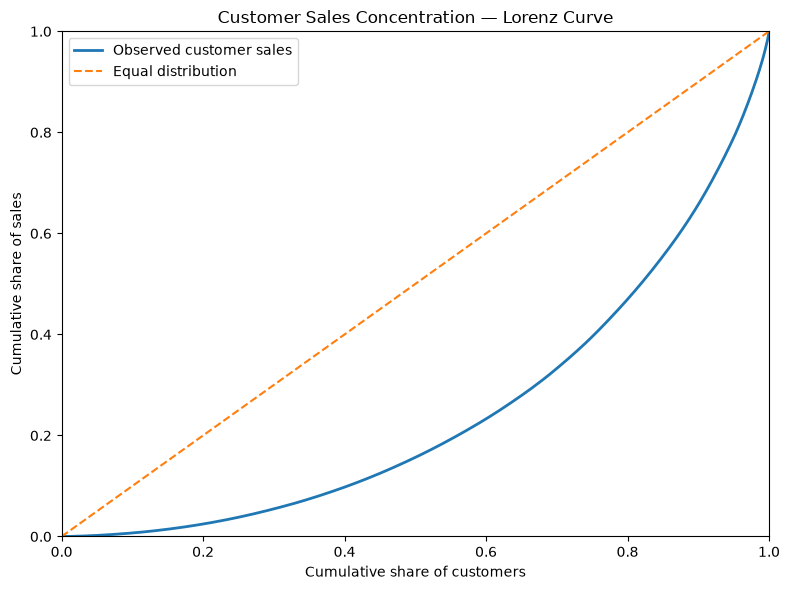

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/01_customer_value_concentration.png


In [7]:
# Lorenz curve

lorenz_values = np.sort(
    value_df["total_spend"].to_numpy(
        dtype=float
    )
)

lorenz_sales = np.insert(
    np.cumsum(lorenz_values)
    / lorenz_values.sum(),
    0,
    0,
)

lorenz_customers = np.linspace(
    0,
    1,
    len(lorenz_sales)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    lorenz_customers,
    lorenz_sales,
    linewidth=2,
    label="Observed customer sales",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Equal distribution",
)

ax.set_title(
    "Customer Sales Concentration — Lorenz Curve"
)

ax.set_xlabel(
    "Cumulative share of customers"
)

ax.set_ylabel(
    "Cumulative share of sales"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "01_customer_value_concentration.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [8]:
# Export reproducible summary tables

tables_dir = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

concentration_summary.to_csv(
    tables_dir
    / "01_customer_value_concentration_summary.csv",
    index=False,
)

decile_summary.to_csv(
    tables_dir
    / "01_customer_value_deciles.csv",
    index=False,
)

print(
    "CUSTOMER VALUE CONCENTRATION"
)

print(
    f"Top 1% sales share: "
    f"{top_1_share:.2%}"
)

print(
    f"Top 5% sales share: "
    f"{top_5_share:.2%}"
)

print(
    f"Top 10% sales share: "
    f"{top_10_share:.2%}"
)

print(
    f"Top 20% sales share: "
    f"{top_20_share:.2%}"
)

print(
    f"Mean customer sales: "
    f"{mean_spend:,.2f}"
)

print(
    f"Median customer sales: "
    f"{median_spend:,.2f}"
)

print(
    f"Gini coefficient: "
    f"{gini:.4f}"
)


CUSTOMER VALUE CONCENTRATION
Top 1% sales share: 6.01%
Top 5% sales share: 21.07%
Top 10% sales share: 34.29%
Top 20% sales share: 53.05%
Mean customer sales: 3,222.98
Median customer sales: 2,157.75
Gini coefficient: 0.5028


### Interpretation — Customer Value Concentration

Customer-attributed retailer sales are meaningfully concentrated rather than evenly distributed across the customer base.

- The top 20% of customers generate 53.05% of total sales.
- The top 10% generate 34.29%.
- Mean customer sales (3,222.98) are materially above the median (2,157.75), indicating a right-skewed value distribution.
- The Gini coefficient is 0.5028, confirming substantial concentration.

This is a provisional pre-segmentation finding. Later segmentation will determine whether this concentration corresponds to a distinct high-value behavioral group rather than treating high spend alone as a segment definition.


## 5.2 Purchase Frequency and Customer Value

**Question:** How are purchase frequency and total customer value related?

Because both behavioral measures are non-negative and may be skewed, the relationship is evaluated using:

- Spearman rank correlation on the original metrics;
- Pearson correlation after `log1p` transformation as a descriptive robustness check;
- customer frequency quintiles;
- a scatter plot on logarithmic axes.

Correlation here is descriptive and must not be interpreted causally.


In [9]:
from scipy.stats import spearmanr, pearsonr

frequency_value = customer_metrics[
    [
        "customer_id",
        "purchase_frequency",
        "total_spend",
        "total_transactions",
    ]
].copy()

spearman_result = spearmanr(
    frequency_value["purchase_frequency"],
    frequency_value["total_spend"],
)

log_frequency = np.log1p(
    frequency_value["purchase_frequency"]
)

log_spend = np.log1p(
    frequency_value["total_spend"]
)

pearson_log_result = pearsonr(
    log_frequency,
    log_spend,
)

print("FREQUENCY VS CUSTOMER VALUE")
print(
    f"Spearman correlation: "
    f"{spearman_result.statistic:.4f}"
)
print(
    f"Log-scale Pearson correlation: "
    f"{pearson_log_result.statistic:.4f}"
)


FREQUENCY VS CUSTOMER VALUE
Spearman correlation: 0.7956
Log-scale Pearson correlation: 0.7532


In [10]:
# Compare customer value across purchase-frequency quintiles.

frequency_value["frequency_quintile"] = pd.qcut(
    frequency_value["purchase_frequency"],
    q=5,
    duplicates="drop",
)

frequency_quintile_summary = (
    frequency_value
    .groupby(
        "frequency_quintile",
        observed=True,
    )
    .agg(
        customers=("customer_id", "size"),
        median_purchase_frequency=(
            "purchase_frequency",
            "median",
        ),
        median_total_spend=(
            "total_spend",
            "median",
        ),
        mean_total_spend=(
            "total_spend",
            "mean",
        ),
        median_transactions=(
            "total_transactions",
            "median",
        ),
    )
    .reset_index()
)

frequency_quintile_summary["frequency_group"] = [
    f"Q{i}"
    for i in range(
        1,
        len(frequency_quintile_summary) + 1
    )
]

display(
    frequency_quintile_summary[
        [
            "frequency_group",
            "customers",
            "median_purchase_frequency",
            "median_total_spend",
            "mean_total_spend",
            "median_transactions",
        ]
    ]
)


,frequency_group,customers,median_purchase_frequency,median_total_spend,mean_total_spend,median_transactions
0,Q1,500,1.7143,500.1550,694.6127,20.0000
1,Q2,502,2.6875,"1,264.6900","1,563.6840",46.0000
2,Q3,498,3.9555,"2,259.9250","2,687.8086",81.0000
3,Q4,500,6.0465,"3,442.9250","4,009.7461",127.5000
4,Q5,500,10.8452,"6,016.4050","7,163.5327",229.5000


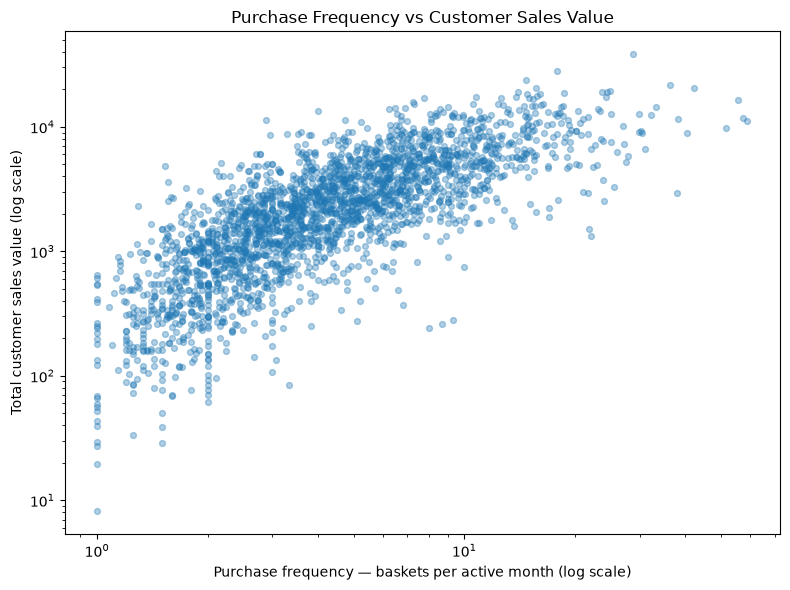

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/02_frequency_vs_customer_value.png


In [11]:
# Purpose:
# Show whether higher purchase frequency is associated with
# higher total customer-attributed retailer sales.

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    frequency_value["purchase_frequency"],
    frequency_value["total_spend"],
    alpha=0.35,
    s=18,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title(
    "Purchase Frequency vs Customer Sales Value"
)

ax.set_xlabel(
    "Purchase frequency — baskets per active month (log scale)"
)

ax.set_ylabel(
    "Total customer sales value (log scale)"
)

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "02_frequency_vs_customer_value.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [12]:
# Export frequency-value summary.

frequency_output = (
    frequency_quintile_summary[
        [
            "frequency_group",
            "customers",
            "median_purchase_frequency",
            "median_total_spend",
            "mean_total_spend",
            "median_transactions",
        ]
    ]
    .copy()
)

frequency_output.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "02_frequency_value_quintiles.csv",
    index=False,
)

lowest_group = frequency_output.iloc[0]
highest_group = frequency_output.iloc[-1]

print("FREQUENCY QUINTILE COMPARISON")
print(
    f"Lowest-frequency group median frequency: "
    f"{lowest_group['median_purchase_frequency']:.2f}"
)
print(
    f"Lowest-frequency group median sales: "
    f"{lowest_group['median_total_spend']:,.2f}"
)
print(
    f"Highest-frequency group median frequency: "
    f"{highest_group['median_purchase_frequency']:.2f}"
)
print(
    f"Highest-frequency group median sales: "
    f"{highest_group['median_total_spend']:,.2f}"
)

median_sales_ratio = (
    highest_group["median_total_spend"]
    / lowest_group["median_total_spend"]
)

print(
    f"Highest / lowest median sales ratio: "
    f"{median_sales_ratio:.2f}x"
)


FREQUENCY QUINTILE COMPARISON
Lowest-frequency group median frequency: 1.71
Lowest-frequency group median sales: 500.15
Highest-frequency group median frequency: 10.85
Highest-frequency group median sales: 6,016.41
Highest / lowest median sales ratio: 12.03x


### Interpretation — Purchase Frequency and Customer Value

Purchase frequency has a strong positive association with total customer-attributed retailer sales value.

- Spearman rank correlation is 0.7956.
- Pearson correlation after `log1p` transformation is 0.7532.
- The highest-frequency customer group has median sales of 6,016.41 versus 500.15 in the lowest-frequency group, a 12.03x difference.

This relationship is descriptive rather than causal. Total customer value is jointly influenced by frequency, active duration and basket value, so frequency should not be interpreted as the sole driver of the observed sales difference.

Segmentation will later test whether high-frequency behavior forms a distinct and commercially interpretable customer profile when considered jointly with recency, spend, basket value, category diversity and promotion behavior.


## 5.3 Average Basket Value Variation

**Question:** How does average basket value vary across consumers?

The analysis reviews:

- central tendency;
- percentile spread;
- interquartile range;
- upper-tail behavior;
- the ratio between high- and low-basket-value customers.

The purpose is to distinguish customer value generated through larger baskets from value generated primarily through higher purchase frequency.


In [13]:
basket_value = customer_metrics[
    [
        "customer_id",
        "average_basket_value",
        "total_spend",
        "total_transactions",
    ]
].copy()

basket_percentiles = (
    basket_value["average_basket_value"]
    .quantile(
        [
            0.01,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

basket_mean = (
    basket_value["average_basket_value"]
    .mean()
)

basket_median = (
    basket_value["average_basket_value"]
    .median()
)

basket_std = (
    basket_value["average_basket_value"]
    .std()
)

basket_iqr = (
    basket_percentiles.loc[0.75]
    - basket_percentiles.loc[0.25]
)

basket_cv = (
    basket_std / basket_mean
)

basket_p90_p10_ratio = (
    basket_percentiles.loc[0.90]
    / basket_percentiles.loc[0.10]
)

basket_summary = pd.DataFrame(
    {
        "metric": [
            "Mean average basket value",
            "Median average basket value",
            "P10 average basket value",
            "P25 average basket value",
            "P75 average basket value",
            "P90 average basket value",
            "P95 average basket value",
            "P99 average basket value",
            "Interquartile range",
            "Coefficient of variation",
            "P90 / P10 ratio",
            "Minimum",
            "Maximum",
        ],
        "value": [
            basket_mean,
            basket_median,
            basket_percentiles.loc[0.10],
            basket_percentiles.loc[0.25],
            basket_percentiles.loc[0.75],
            basket_percentiles.loc[0.90],
            basket_percentiles.loc[0.95],
            basket_percentiles.loc[0.99],
            basket_iqr,
            basket_cv,
            basket_p90_p10_ratio,
            basket_value[
                "average_basket_value"
            ].min(),
            basket_value[
                "average_basket_value"
            ].max(),
        ],
    }
)

basket_summary


,metric,value
0,Mean average basket value,31.6901
1,Median average basket value,27.4700
2,P10 average basket value,12.5940
3,P25 average basket value,18.4037
4,P75 average basket value,40.6193
5,P90 average basket value,55.4541
6,P95 average basket value,67.6013
7,P99 average basket value,99.6361
8,Interquartile range,22.2156
9,Coefficient of variation,0.6025


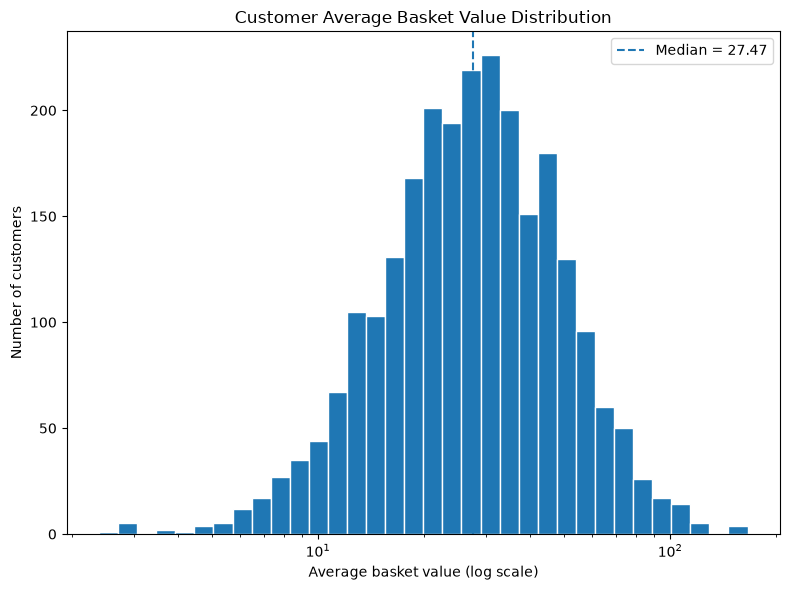

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/03_average_basket_value_distribution.png


In [14]:
# Purpose:
# Show the full customer-level basket-value distribution while
# preserving visibility of the right tail.

basket_values = basket_value[
    "average_basket_value"
].to_numpy(dtype=float)

positive_basket_values = basket_values[
    basket_values > 0
]

log_bins = np.geomspace(
    positive_basket_values.min(),
    positive_basket_values.max(),
    35,
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    positive_basket_values,
    bins=log_bins,
    edgecolor="white",
)

ax.set_xscale("log")

ax.axvline(
    basket_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Median = {basket_median:,.2f}"
    ),
)

ax.set_title(
    "Customer Average Basket Value Distribution"
)

ax.set_xlabel(
    "Average basket value (log scale)"
)

ax.set_ylabel(
    "Number of customers"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "03_average_basket_value_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [15]:
# Compare basket value across customer quintiles.

basket_value["basket_value_quintile"] = pd.qcut(
    basket_value["average_basket_value"],
    q=5,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest",
    ],
)

basket_quintile_summary = (
    basket_value
    .groupby(
        "basket_value_quintile",
        observed=True,
    )
    .agg(
        customers=("customer_id", "size"),
        median_average_basket_value=(
            "average_basket_value",
            "median",
        ),
        median_total_spend=(
            "total_spend",
            "median",
        ),
        median_transactions=(
            "total_transactions",
            "median",
        ),
    )
    .reset_index()
)

basket_quintile_summary


,basket_value_quintile,customers,median_average_basket_value,median_total_spend,median_transactions
0,Q1 - Lowest,500,12.5900,787.4350,68.0000
1,Q2,500,20.1209,"1,756.6000",86.5000
2,Q3,500,27.4700,"2,265.9550",86.0000
3,Q4,500,36.7166,"3,007.2900",81.0000
4,Q5 - Highest,500,55.4860,"4,275.7550",69.5000


In [16]:
# Export reproducible basket-value summaries.

basket_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "03_average_basket_value_summary.csv",
    index=False,
)

basket_quintile_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "03_average_basket_value_quintiles.csv",
    index=False,
)

print("AVERAGE BASKET VALUE VARIATION")

print(
    f"Mean average basket value: "
    f"{basket_mean:,.2f}"
)

print(
    f"Median average basket value: "
    f"{basket_median:,.2f}"
)

print(
    f"P10 average basket value: "
    f"{basket_percentiles.loc[0.10]:,.2f}"
)

print(
    f"P90 average basket value: "
    f"{basket_percentiles.loc[0.90]:,.2f}"
)

print(
    f"P99 average basket value: "
    f"{basket_percentiles.loc[0.99]:,.2f}"
)

print(
    f"Interquartile range: "
    f"{basket_iqr:,.2f}"
)

print(
    f"Coefficient of variation: "
    f"{basket_cv:.4f}"
)

print(
    f"P90 / P10 ratio: "
    f"{basket_p90_p10_ratio:.2f}x"
)

print(
    f"Minimum average basket value: "
    f"{basket_value['average_basket_value'].min():,.2f}"
)

print(
    f"Maximum average basket value: "
    f"{basket_value['average_basket_value'].max():,.2f}"
)


AVERAGE BASKET VALUE VARIATION
Mean average basket value: 31.69
Median average basket value: 27.47
P10 average basket value: 12.59
P90 average basket value: 55.45
P99 average basket value: 99.64
Interquartile range: 22.22
Coefficient of variation: 0.6025
P90 / P10 ratio: 4.40x
Minimum average basket value: 2.39
Maximum average basket value: 165.83


### Interpretation — Average Basket Value Variation

Average basket value varies materially across customers.

- Median customer average basket value is 27.47.
- P10 is 12.59 and P90 is 55.45, producing a 4.40x P90/P10 ratio.
- P99 reaches 99.64.
- The coefficient of variation is 0.6025.
- Mean basket value (31.69) exceeds the median, consistent with a right-skewed distribution.

This indicates that customer value is not explained by purchase frequency alone. Some customers generate value through larger baskets, while others may generate value through more frequent purchase occasions. Segmentation should therefore preserve both frequency and basket value as separate behavioral dimensions.


## 5.4 Category Diversity

**Question:** How diverse are customer category portfolios?

`category_diversity` measures the number of distinct valid product categories purchased by each customer.

The analysis reviews:

- central tendency and percentile spread;
- the range of customer portfolio breadth;
- customer distribution across diversity quintiles;
- the descriptive relationship between category diversity and total customer sales.

The relationship with sales is descriptive only and does not imply that purchasing more categories causes higher customer value.


In [17]:
from scipy.stats import spearmanr

diversity_df = customer_metrics[
    [
        "customer_id",
        "category_diversity",
        "total_spend",
        "purchase_frequency",
    ]
].copy()

diversity_percentiles = (
    diversity_df["category_diversity"]
    .quantile(
        [
            0.01,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

diversity_mean = (
    diversity_df["category_diversity"]
    .mean()
)

diversity_median = (
    diversity_df["category_diversity"]
    .median()
)

diversity_iqr = (
    diversity_percentiles.loc[0.75]
    - diversity_percentiles.loc[0.25]
)

diversity_spend_spearman = spearmanr(
    diversity_df["category_diversity"],
    diversity_df["total_spend"],
)

diversity_summary = pd.DataFrame(
    {
        "metric": [
            "Mean category diversity",
            "Median category diversity",
            "P10 category diversity",
            "P25 category diversity",
            "P75 category diversity",
            "P90 category diversity",
            "P95 category diversity",
            "P99 category diversity",
            "Interquartile range",
            "Minimum category diversity",
            "Maximum category diversity",
            "Diversity vs sales Spearman correlation",
        ],
        "value": [
            diversity_mean,
            diversity_median,
            diversity_percentiles.loc[0.10],
            diversity_percentiles.loc[0.25],
            diversity_percentiles.loc[0.75],
            diversity_percentiles.loc[0.90],
            diversity_percentiles.loc[0.95],
            diversity_percentiles.loc[0.99],
            diversity_iqr,
            diversity_df["category_diversity"].min(),
            diversity_df["category_diversity"].max(),
            diversity_spend_spearman.statistic,
        ],
    }
)

diversity_summary


,metric,value
0,Mean category diversity,114.6192
1,Median category diversity,117.0000
2,P10 category diversity,52.0000
3,P25 category diversity,83.0000
4,P75 category diversity,149.0000
5,P90 category diversity,172.1000
6,P95 category diversity,187.0000
7,P99 category diversity,207.0000
8,Interquartile range,66.0000
9,Minimum category diversity,3.0000


In [18]:
# Compare customer behavior across category-diversity quintiles.

diversity_df["diversity_quintile"] = pd.qcut(
    diversity_df["category_diversity"],
    q=5,
    duplicates="drop",
)

diversity_quintile_summary = (
    diversity_df
    .groupby(
        "diversity_quintile",
        observed=True,
    )
    .agg(
        customers=("customer_id", "size"),
        median_category_diversity=(
            "category_diversity",
            "median",
        ),
        median_total_spend=(
            "total_spend",
            "median",
        ),
        median_purchase_frequency=(
            "purchase_frequency",
            "median",
        ),
    )
    .reset_index()
)

diversity_quintile_summary["diversity_group"] = [
    f"Q{i}"
    for i in range(
        1,
        len(diversity_quintile_summary) + 1
    )
]

diversity_quintile_summary


,diversity_quintile,customers,median_category_diversity,median_total_spend,median_purchase_frequency,diversity_group
0,"(2.999, 74.0]",504,52.0000,394.4850,1.9404,Q1
1,"(74.0, 104.0]",504,91.0000,"1,158.2200",2.8536,Q2
2,"(104.0, 129.0]",498,117.0000,"2,102.8800",3.9524,Q3
3,"(129.0, 155.0]",504,143.0000,"3,686.4550",5.4664,Q4
4,"(155.0, 242.0]",490,173.0000,"7,054.7050",8.5812,Q5


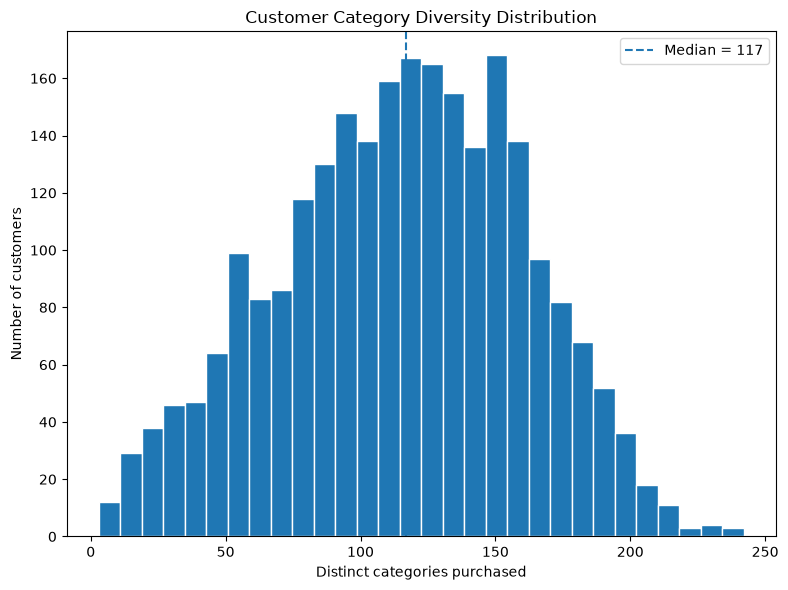

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/04_category_diversity_distribution.png


In [19]:
# Purpose:
# Show how broadly the number of purchased categories varies
# across the customer base.

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    diversity_df["category_diversity"],
    bins=30,
    edgecolor="white",
)

ax.axvline(
    diversity_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Median = {diversity_median:,.0f}"
    ),
)

ax.set_title(
    "Customer Category Diversity Distribution"
)

ax.set_xlabel(
    "Distinct categories purchased"
)

ax.set_ylabel(
    "Number of customers"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "04_category_diversity_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [20]:
# Export reproducible category-diversity summaries.

diversity_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "04_category_diversity_summary.csv",
    index=False,
)

diversity_quintile_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "04_category_diversity_quintiles.csv",
    index=False,
)

lowest_group = diversity_quintile_summary.iloc[0]
highest_group = diversity_quintile_summary.iloc[-1]

diversity_sales_ratio = (
    highest_group["median_total_spend"]
    / lowest_group["median_total_spend"]
)

print("CATEGORY DIVERSITY")

print(
    f"Mean category diversity: "
    f"{diversity_mean:.2f}"
)

print(
    f"Median category diversity: "
    f"{diversity_median:.0f}"
)

print(
    f"P10 category diversity: "
    f"{diversity_percentiles.loc[0.10]:.0f}"
)

print(
    f"P90 category diversity: "
    f"{diversity_percentiles.loc[0.90]:.0f}"
)

print(
    f"P99 category diversity: "
    f"{diversity_percentiles.loc[0.99]:.0f}"
)

print(
    f"Minimum category diversity: "
    f"{diversity_df['category_diversity'].min():.0f}"
)

print(
    f"Maximum category diversity: "
    f"{diversity_df['category_diversity'].max():.0f}"
)

print(
    f"Diversity vs sales Spearman correlation: "
    f"{diversity_spend_spearman.statistic:.4f}"
)

print(
    f"Lowest-diversity group median sales: "
    f"{lowest_group['median_total_spend']:,.2f}"
)

print(
    f"Highest-diversity group median sales: "
    f"{highest_group['median_total_spend']:,.2f}"
)

print(
    f"Highest / lowest diversity-group "
    f"median sales ratio: "
    f"{diversity_sales_ratio:.2f}x"
)


CATEGORY DIVERSITY
Mean category diversity: 114.62
Median category diversity: 117
P10 category diversity: 52
P90 category diversity: 172
P99 category diversity: 207
Minimum category diversity: 3
Maximum category diversity: 242
Diversity vs sales Spearman correlation: 0.9217
Lowest-diversity group median sales: 394.49
Highest-diversity group median sales: 7,054.70
Highest / lowest diversity-group median sales ratio: 17.88x


### Interpretation — Category Diversity

Customer category portfolios vary substantially across the population.

- Median category diversity is 117 categories.
- P10 is 52 categories and P90 is 172.
- The full observed range is 3 to 242 categories.
- Category diversity and total customer sales have a very strong positive Spearman association of 0.9217.
- Median customer sales are 7,054.70 in the highest-diversity group versus 394.49 in the lowest-diversity group, a 17.88x difference.

This relationship should not be interpreted causally. Both total sales and category diversity accumulate with customer activity and observed purchasing history. The result therefore indicates a strong association between breadth of engagement and overall customer activity/value, rather than evidence that expanding category count itself causes higher sales.

Segmentation will evaluate category diversity jointly with frequency, spend, recency, basket value and promotion behavior.


## 5.5 Promotion Dependence

**Question:** How widespread is promotion dependence?

Two complementary measures are used:

- `promotion_purchase_share`: share of customer baskets containing at least one promotional line;
- `promotion_spend_share`: share of customer-attributed retailer sales generated by promotional lines.

The analysis evaluates the distribution of both measures and the number of customers whose observed behavior is concentrated in promotional purchases.

Promotion dependence is a descriptive behavioral concept. It does not imply low profitability, incremental promotion lift or causal promotion response.


In [21]:
from scipy.stats import spearmanr

promotion_df = customer_metrics[
    [
        "customer_id",
        "promotion_purchase_share",
        "promotion_spend_share",
        "total_spend",
    ]
].copy()

purchase_share = promotion_df[
    "promotion_purchase_share"
]

spend_share = promotion_df[
    "promotion_spend_share"
]

purchase_percentiles = purchase_share.quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

spend_percentiles = spend_share.quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

promotion_share_correlation = spearmanr(
    purchase_share,
    spend_share,
)

promotion_summary = pd.DataFrame(
    {
        "metric": [
            "Mean promotion purchase share",
            "Median promotion purchase share",
            "P10 promotion purchase share",
            "P90 promotion purchase share",
            "Mean promotion spend share",
            "Median promotion spend share",
            "P10 promotion spend share",
            "P90 promotion spend share",
            "Purchase vs spend share Spearman correlation",
        ],
        "value": [
            purchase_share.mean(),
            purchase_share.median(),
            purchase_percentiles.loc[0.10],
            purchase_percentiles.loc[0.90],
            spend_share.mean(),
            spend_share.median(),
            spend_percentiles.loc[0.10],
            spend_percentiles.loc[0.90],
            promotion_share_correlation.statistic,
        ],
    }
)

promotion_summary


,metric,value
0,Mean promotion purchase share,0.8450
1,Median promotion purchase share,0.8656
2,P10 promotion purchase share,0.7058
3,P90 promotion purchase share,0.9605
4,Mean promotion spend share,0.5011
5,Median promotion spend share,0.5021
6,P10 promotion spend share,0.3540
7,P90 promotion spend share,0.6474
8,Purchase vs spend share Spearman correlation,0.3453


In [22]:
# Descriptive threshold profile.
# Thresholds are used only to summarize prevalence, not to
# define final business segments.

threshold_summary = pd.DataFrame(
    {
        "measure": [
            "Promo baskets >= 50%",
            "Promo baskets >= 75%",
            "Promo spend >= 50%",
            "Promo spend >= 75%",
            "Both shares >= 50%",
        ],
        "customers": [
            (purchase_share >= 0.50).sum(),
            (purchase_share >= 0.75).sum(),
            (spend_share >= 0.50).sum(),
            (spend_share >= 0.75).sum(),
            (
                (purchase_share >= 0.50)
                & (spend_share >= 0.50)
            ).sum(),
        ],
    }
)

threshold_summary["customer_share"] = (
    threshold_summary["customers"]
    / len(promotion_df)
)

threshold_summary


,measure,customers,customer_share
0,Promo baskets >= 50%,2476,0.9904
1,Promo baskets >= 75%,2110,0.8440
2,Promo spend >= 50%,1264,0.5056
3,Promo spend >= 75%,53,0.0212
4,Both shares >= 50%,1261,0.5044


In [23]:
# Create common dependence bands for both promotion measures.

band_edges = [0, 0.25, 0.50, 0.75, 1.0000001]

band_labels = [
    "<25%",
    "25–50%",
    "50–75%",
    "75–100%",
]

promotion_df["purchase_share_band"] = pd.cut(
    promotion_df["promotion_purchase_share"],
    bins=band_edges,
    labels=band_labels,
    include_lowest=True,
    right=False,
)

promotion_df["spend_share_band"] = pd.cut(
    promotion_df["promotion_spend_share"],
    bins=band_edges,
    labels=band_labels,
    include_lowest=True,
    right=False,
)

purchase_band_summary = (
    promotion_df["purchase_share_band"]
    .value_counts(sort=False)
    .rename("purchase_customers")
)

spend_band_summary = (
    promotion_df["spend_share_band"]
    .value_counts(sort=False)
    .rename("spend_customers")
)

promotion_band_summary = pd.concat(
    [
        purchase_band_summary,
        spend_band_summary,
    ],
    axis=1,
).reset_index(names="promotion_share_band")

promotion_band_summary[
    "purchase_customer_share"
] = (
    promotion_band_summary["purchase_customers"]
    / len(promotion_df)
)

promotion_band_summary[
    "spend_customer_share"
] = (
    promotion_band_summary["spend_customers"]
    / len(promotion_df)
)

promotion_band_summary


,promotion_share_band,purchase_customers,spend_customers,purchase_customer_share,spend_customer_share
0,<25%,1,47,0.0004,0.0188
1,25–50%,23,1189,0.0092,0.4756
2,50–75%,366,1211,0.1464,0.4844
3,75–100%,2110,53,0.8440,0.0212


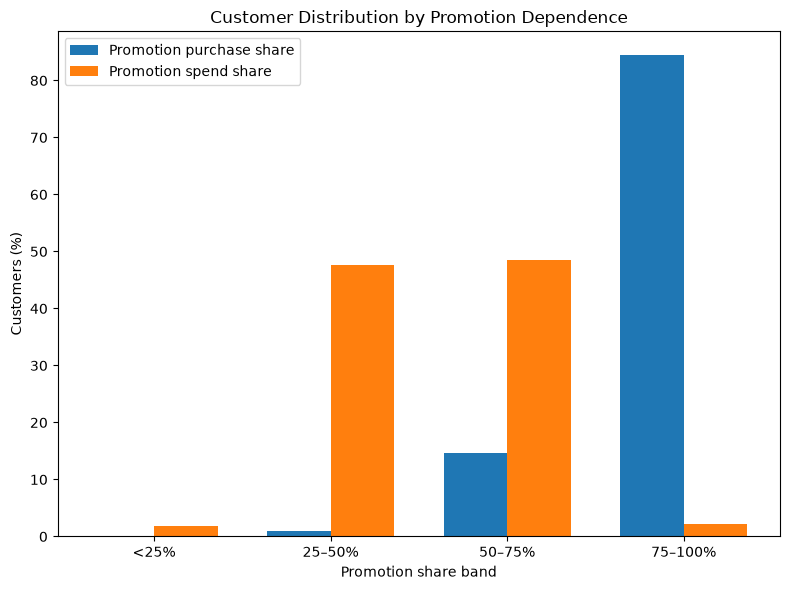

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/05_promotion_dependence_distribution.png


In [24]:
# Purpose:
# Compare how customers are distributed across promotion
# purchase-share and promotion spend-share bands.

x = np.arange(
    len(promotion_band_summary)
)

width = 0.36

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    x - width / 2,
    promotion_band_summary[
        "purchase_customer_share"
    ] * 100,
    width=width,
    label="Promotion purchase share",
)

ax.bar(
    x + width / 2,
    promotion_band_summary[
        "spend_customer_share"
    ] * 100,
    width=width,
    label="Promotion spend share",
)

ax.set_xticks(x)

ax.set_xticklabels(
    promotion_band_summary[
        "promotion_share_band"
    ]
)

ax.set_title(
    "Customer Distribution by Promotion Dependence"
)

ax.set_xlabel(
    "Promotion share band"
)

ax.set_ylabel(
    "Customers (%)"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "05_promotion_dependence_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [25]:
# Export reproducible promotion summaries.

promotion_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "05_promotion_dependence_summary.csv",
    index=False,
)

threshold_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "05_promotion_dependence_thresholds.csv",
    index=False,
)

promotion_band_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "05_promotion_dependence_bands.csv",
    index=False,
)

print("PROMOTION DEPENDENCE")

print(
    f"Mean promotion purchase share: "
    f"{purchase_share.mean():.2%}"
)

print(
    f"Median promotion purchase share: "
    f"{purchase_share.median():.2%}"
)

print(
    f"P10 promotion purchase share: "
    f"{purchase_percentiles.loc[0.10]:.2%}"
)

print(
    f"P90 promotion purchase share: "
    f"{purchase_percentiles.loc[0.90]:.2%}"
)

print(
    f"Mean promotion spend share: "
    f"{spend_share.mean():.2%}"
)

print(
    f"Median promotion spend share: "
    f"{spend_share.median():.2%}"
)

print(
    f"P10 promotion spend share: "
    f"{spend_percentiles.loc[0.10]:.2%}"
)

print(
    f"P90 promotion spend share: "
    f"{spend_percentiles.loc[0.90]:.2%}"
)

print(
    f"Purchase vs spend share Spearman correlation: "
    f"{promotion_share_correlation.statistic:.4f}"
)

for row in threshold_summary.itertuples(index=False):
    print(
        f"{row.measure}: "
        f"{row.customers} customers "
        f"({row.customer_share:.2%})"
    )


PROMOTION DEPENDENCE
Mean promotion purchase share: 84.50%
Median promotion purchase share: 86.56%
P10 promotion purchase share: 70.58%
P90 promotion purchase share: 96.05%
Mean promotion spend share: 50.11%
Median promotion spend share: 50.21%
P10 promotion spend share: 35.40%
P90 promotion spend share: 64.74%
Purchase vs spend share Spearman correlation: 0.3453
Promo baskets >= 50%: 2476 customers (99.04%)
Promo baskets >= 75%: 2110 customers (84.40%)
Promo spend >= 50%: 1264 customers (50.56%)
Promo spend >= 75%: 53 customers (2.12%)
Both shares >= 50%: 1261 customers (50.44%)


### Interpretation — Promotion Dependence

Promotional basket exposure is widespread, but promotional sales dependence is materially more varied.

- Mean promotion purchase share is 84.50%, and 99.04% of customers have promotions in at least half of their baskets.
- 84.40% of customers have promotions in at least 75% of baskets.
- Mean promotion spend share is 50.11%.
- Only 2.12% of customers have at least 75% of sales on promotional lines.
- Promotion purchase share and promotion spend share have only a modest Spearman association of 0.3453.

This distinction matters: a customer can frequently shop baskets containing promotional items without having most of their total sales value generated by promotional lines.

Promotion exposure and promotion sales dependence should therefore remain separate behavioral dimensions. These measures describe observed purchasing behavior only; they do not establish profitability, incremental lift or causal promotion response.


## 5.6 Historical Value and Recency

**Question:** Are there historically valuable customers with high recency?

For exploratory screening:

- **Historically high value** = customers at or above the 80th percentile of `total_spend`.
- **High recency** = customers at or above the 80th percentile of `recency_days`.

Higher `recency_days` means a longer period since the customer's latest valid purchase relative to the dataset end date.

These percentile thresholds are descriptive screening rules, not final segment definitions or causal evidence of churn.


In [26]:
recency_value = customer_metrics[
    [
        "customer_id",
        "total_spend",
        "recency_days",
        "purchase_frequency",
        "average_basket_value",
        "active_months",
        "promotion_purchase_share",
    ]
].copy()

spend_p80 = recency_value[
    "total_spend"
].quantile(0.80)

spend_p90 = recency_value[
    "total_spend"
].quantile(0.90)

recency_p80 = recency_value[
    "recency_days"
].quantile(0.80)

recency_p90 = recency_value[
    "recency_days"
].quantile(0.90)

recency_value["high_value_p80"] = (
    recency_value["total_spend"]
    >= spend_p80
)

recency_value["high_recency_p80"] = (
    recency_value["recency_days"]
    >= recency_p80
)

recency_value["high_value_high_recency"] = (
    recency_value["high_value_p80"]
    & recency_value["high_recency_p80"]
)

recency_value["high_value_p90"] = (
    recency_value["total_spend"]
    >= spend_p90
)

recency_value["high_recency_p90"] = (
    recency_value["recency_days"]
    >= recency_p90
)

recency_value["strict_high_value_high_recency"] = (
    recency_value["high_value_p90"]
    & recency_value["high_recency_p90"]
)

recency_percentiles = (
    recency_value["recency_days"]
    .quantile(
        [
            0.50,
            0.75,
            0.80,
            0.90,
            0.95,
            0.99,
        ]
    )
)

recency_percentiles


0.5000     6.0000
0.7500    20.0000
0.8000    27.0000
0.9000    62.0000
0.9500   117.0500
0.9900   317.0500
Name: recency_days, dtype: float64

In [27]:
# Four-quadrant descriptive profile using P80 thresholds.

recency_value["value_recency_group"] = np.select(
    [
        (
            recency_value["high_value_p80"]
            & recency_value["high_recency_p80"]
        ),
        (
            recency_value["high_value_p80"]
            & ~recency_value["high_recency_p80"]
        ),
        (
            ~recency_value["high_value_p80"]
            & recency_value["high_recency_p80"]
        ),
    ],
    [
        "High value / High recency",
        "High value / Lower recency",
        "Lower value / High recency",
    ],
    default="Lower value / Lower recency",
)

value_recency_summary = (
    recency_value
    .groupby(
        "value_recency_group",
        observed=True,
    )
    .agg(
        customers=("customer_id", "size"),
        historical_sales=("total_spend", "sum"),
        median_total_spend=("total_spend", "median"),
        median_recency_days=("recency_days", "median"),
        median_purchase_frequency=(
            "purchase_frequency",
            "median",
        ),
        median_average_basket_value=(
            "average_basket_value",
            "median",
        ),
        median_active_months=(
            "active_months",
            "median",
        ),
    )
    .reset_index()
)

value_recency_summary[
    "customer_share"
] = (
    value_recency_summary["customers"]
    / len(recency_value)
)

value_recency_summary[
    "historical_sales_share"
] = (
    value_recency_summary["historical_sales"]
    / recency_value["total_spend"].sum()
)

value_recency_summary


,value_recency_group,customers,historical_sales,median_total_spend,median_recency_days,median_purchase_frequency,median_average_basket_value,median_active_months,customer_share,historical_sales_share
0,High value / High recency,18,"133,715.4900","6,698.8150",42.5000,7.5350,45.1622,20.0000,0.0072,0.0166
1,High value / Lower recency,482,"4,140,468.7300","7,500.1550",2.0000,9.0208,39.2269,22.0000,0.1928,0.5139
2,Lower value / High recency,491,"535,181.0200",693.8600,61.0000,2.2000,24.9012,13.0000,0.1964,0.0664
3,Lower value / Lower recency,1509,"3,248,078.5600","1,978.8300",5.0000,3.6471,25.1657,20.0000,0.6036,0.4031


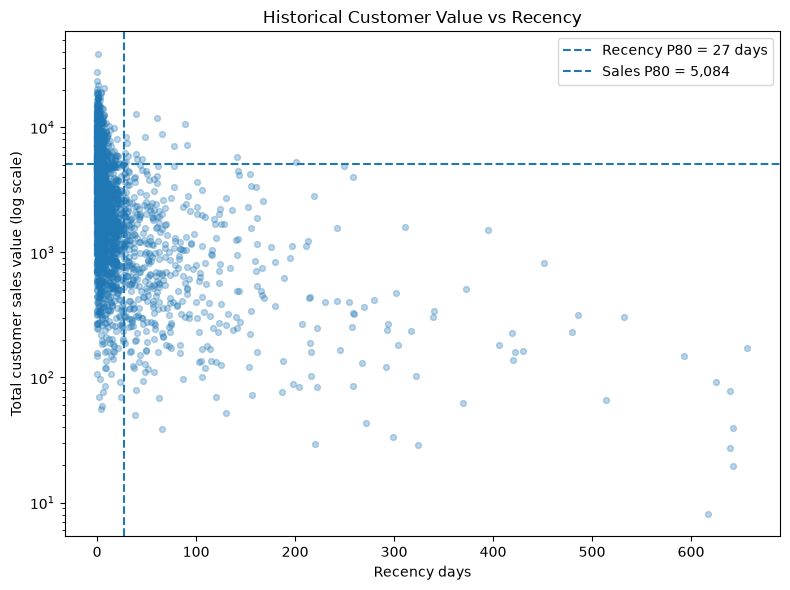

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/06_historical_value_vs_recency.png


In [28]:
# Purpose:
# Identify customers combining high historical value with
# a long time since their latest observed purchase.

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    recency_value["recency_days"],
    recency_value["total_spend"],
    alpha=0.30,
    s=18,
)

ax.axvline(
    recency_p80,
    linestyle="--",
    linewidth=1.5,
    label=f"Recency P80 = {recency_p80:.0f} days",
)

ax.axhline(
    spend_p80,
    linestyle="--",
    linewidth=1.5,
    label=f"Sales P80 = {spend_p80:,.0f}",
)

ax.set_yscale("log")

ax.set_title(
    "Historical Customer Value vs Recency"
)

ax.set_xlabel(
    "Recency days"
)

ax.set_ylabel(
    "Total customer sales value (log scale)"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "06_historical_value_vs_recency.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [29]:
# Export reproducible recency/value summaries.

value_recency_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "06_value_recency_groups.csv",
    index=False,
)

high_value_high_recency = recency_value[
    recency_value[
        "high_value_high_recency"
    ]
].copy()

high_value_high_recency.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "06_high_value_high_recency_customers.csv",
    index=False,
)

strict_group = recency_value[
    recency_value[
        "strict_high_value_high_recency"
    ]
]

group_sales = (
    high_value_high_recency[
        "total_spend"
    ].sum()
)

group_sales_share = (
    group_sales
    / recency_value["total_spend"].sum()
)

print("HISTORICAL VALUE AND RECENCY")

print(
    f"Median recency: "
    f"{recency_percentiles.loc[0.50]:.0f} days"
)

print(
    f"P80 recency threshold: "
    f"{recency_p80:.0f} days"
)

print(
    f"P90 recency threshold: "
    f"{recency_p90:.0f} days"
)

print(
    f"P80 historical sales threshold: "
    f"{spend_p80:,.2f}"
)

print(
    f"High-value / high-recency customers: "
    f"{len(high_value_high_recency)} "
    f"({len(high_value_high_recency) / len(recency_value):.2%})"
)

print(
    f"Historical sales represented by this group: "
    f"{group_sales:,.2f} "
    f"({group_sales_share:.2%})"
)

print(
    f"Median sales in this group: "
    f"{high_value_high_recency['total_spend'].median():,.2f}"
)

print(
    f"Median recency in this group: "
    f"{high_value_high_recency['recency_days'].median():.0f} days"
)

print(
    f"Strict P90/P90 overlap customers: "
    f"{len(strict_group)} "
    f"({len(strict_group) / len(recency_value):.2%})"
)


HISTORICAL VALUE AND RECENCY
Median recency: 6 days
P80 recency threshold: 27 days
P90 recency threshold: 62 days
P80 historical sales threshold: 5,083.86
High-value / high-recency customers: 18 (0.72%)
Historical sales represented by this group: 133,715.49 (1.66%)
Median sales in this group: 6,698.82
Median recency in this group: 42 days
Strict P90/P90 overlap customers: 2 (0.08%)


## 6. Candidate Insights

The following findings are **provisional pre-segmentation insights**. They describe observed customer behavior and are not yet final business recommendations.

### Candidate Insight 1 — Customer value is concentrated

**Finding**  
A relatively small part of the customer base accounts for a disproportionate share of retailer sales value.

**Evidence**  
The top 20% of customers generate 53.05% of total sales, while the top 10% generate 34.29%. Mean customer sales are 3,222.98 versus a median of 2,157.75, and the customer-sales Gini coefficient is 0.5028.

**Business relevance**  
Customer value is not evenly distributed, so treating the full customer base as behaviorally homogeneous could obscure commercially important differences.

**Next analysis**  
Segmentation will test whether the higher-value population forms one or more distinct behavioral groups when spend is considered jointly with frequency, recency, basket value, category diversity and promotion behavior.

---

### Candidate Insight 2 — Purchase frequency strongly differentiates customer value

**Finding**  
Customers who purchase more frequently tend to have materially higher total retailer sales value.

**Evidence**  
Purchase frequency and total sales have a Spearman correlation of 0.7956. The highest-frequency group has median customer sales of 6,016.41 versus 500.15 in the lowest-frequency group, a 12.03x difference.

**Business relevance**  
Purchase frequency appears to be an important dimension of customer engagement and value, although the relationship is descriptive rather than causal.

**Next analysis**  
Segmentation will determine whether high-frequency customers remain behaviorally distinct after accounting for basket value, category breadth, recency and promotion dependence.

---

### Candidate Insight 3 — Broad category engagement is strongly associated with customer value

**Finding**  
Customers purchasing across a broader range of categories also tend to have much higher historical sales value.

**Evidence**  
Category diversity and total customer sales have a Spearman correlation of 0.9217. Median sales are 7,054.70 in the highest-diversity group versus 394.49 in the lowest-diversity group, a 17.88x difference.

**Business relevance**  
Category breadth is a strong marker of observed customer engagement, but both category diversity and total sales accumulate with purchasing activity and observed history.

**Next analysis**  
Segmentation will assess whether category diversity adds an interpretable engagement dimension after it is considered jointly with frequency and total spend rather than treating this association as causal.

---

### Candidate Insight 4 — Promotion exposure and promotion sales dependence are distinct behaviors

**Finding**  
Promotional baskets are widespread across the customer base, but customers differ substantially in how much of their sales value comes from promotional lines.

**Evidence**  
Mean promotion purchase share is 84.50%, and 84.40% of customers have promotions in at least 75% of their baskets. Mean promotion spend share is 50.11%, while only 2.12% of customers have at least 75% of sales on promotional lines. The two promotion measures have a Spearman correlation of only 0.3453.

**Business relevance**  
Frequent exposure to promotional baskets should not automatically be interpreted as strong promotion dependence. Basket-level promotion exposure and promotional sales reliance capture different aspects of behavior.

**Next analysis**  
Segmentation and the later promotion analysis will compare these measures separately and test whether distinct customer groups exhibit meaningfully different promotional behavior.

---

### Candidate Insight 5 — A small historically valuable high-recency pocket exists

**Finding**  
A small subset of historically valuable customers has gone materially longer than most customers without a purchase.

**Evidence**  
Using P80 thresholds for both historical sales and recency identifies 18 customers (0.72% of the customer base). They represent 133,715.49 in historical sales, or 1.66% of the dataset total, with median historical sales of 6,698.82 and median recency of 42 days. Under stricter P90/P90 thresholds, only two customers qualify.

**Business relevance**  
This is not evidence of a broad churn problem, but it identifies a narrowly defined population whose historical value may justify closer reactivation analysis.

**Next analysis**  
Segmentation will show whether these customers belong to a coherent behavioral segment. Any future reactivation recommendation must remain descriptive and must not assume churn, incremental lift or causal campaign impact.


In [30]:
# Export candidate insights for downstream project artifacts.

insights_dir = (
    PROJECT_ROOT
    / "outputs"
    / "insights"
)

insights_dir.mkdir(
    parents=True,
    exist_ok=True,
)

candidate_insights_path = (
    insights_dir
    / "01_consumer_behavior_candidate_insights.md"
)

candidate_insights_text = r'''## 6. Candidate Insights

The following findings are **provisional pre-segmentation insights**. They describe observed customer behavior and are not yet final business recommendations.

### Candidate Insight 1 — Customer value is concentrated

**Finding**  
A relatively small part of the customer base accounts for a disproportionate share of retailer sales value.

**Evidence**  
The top 20% of customers generate 53.05% of total sales, while the top 10% generate 34.29%. Mean customer sales are 3,222.98 versus a median of 2,157.75, and the customer-sales Gini coefficient is 0.5028.

**Business relevance**  
Customer value is not evenly distributed, so treating the full customer base as behaviorally homogeneous could obscure commercially important differences.

**Next analysis**  
Segmentation will test whether the higher-value population forms one or more distinct behavioral groups when spend is considered jointly with frequency, recency, basket value, category diversity and promotion behavior.

---

### Candidate Insight 2 — Purchase frequency strongly differentiates customer value

**Finding**  
Customers who purchase more frequently tend to have materially higher total retailer sales value.

**Evidence**  
Purchase frequency and total sales have a Spearman correlation of 0.7956. The highest-frequency group has median customer sales of 6,016.41 versus 500.15 in the lowest-frequency group, a 12.03x difference.

**Business relevance**  
Purchase frequency appears to be an important dimension of customer engagement and value, although the relationship is descriptive rather than causal.

**Next analysis**  
Segmentation will determine whether high-frequency customers remain behaviorally distinct after accounting for basket value, category breadth, recency and promotion dependence.

---

### Candidate Insight 3 — Broad category engagement is strongly associated with customer value

**Finding**  
Customers purchasing across a broader range of categories also tend to have much higher historical sales value.

**Evidence**  
Category diversity and total customer sales have a Spearman correlation of 0.9217. Median sales are 7,054.70 in the highest-diversity group versus 394.49 in the lowest-diversity group, a 17.88x difference.

**Business relevance**  
Category breadth is a strong marker of observed customer engagement, but both category diversity and total sales accumulate with purchasing activity and observed history.

**Next analysis**  
Segmentation will assess whether category diversity adds an interpretable engagement dimension after it is considered jointly with frequency and total spend rather than treating this association as causal.

---

### Candidate Insight 4 — Promotion exposure and promotion sales dependence are distinct behaviors

**Finding**  
Promotional baskets are widespread across the customer base, but customers differ substantially in how much of their sales value comes from promotional lines.

**Evidence**  
Mean promotion purchase share is 84.50%, and 84.40% of customers have promotions in at least 75% of their baskets. Mean promotion spend share is 50.11%, while only 2.12% of customers have at least 75% of sales on promotional lines. The two promotion measures have a Spearman correlation of only 0.3453.

**Business relevance**  
Frequent exposure to promotional baskets should not automatically be interpreted as strong promotion dependence. Basket-level promotion exposure and promotional sales reliance capture different aspects of behavior.

**Next analysis**  
Segmentation and the later promotion analysis will compare these measures separately and test whether distinct customer groups exhibit meaningfully different promotional behavior.

---

### Candidate Insight 5 — A small historically valuable high-recency pocket exists

**Finding**  
A small subset of historically valuable customers has gone materially longer than most customers without a purchase.

**Evidence**  
Using P80 thresholds for both historical sales and recency identifies 18 customers (0.72% of the customer base). They represent 133,715.49 in historical sales, or 1.66% of the dataset total, with median historical sales of 6,698.82 and median recency of 42 days. Under stricter P90/P90 thresholds, only two customers qualify.

**Business relevance**  
This is not evidence of a broad churn problem, but it identifies a narrowly defined population whose historical value may justify closer reactivation analysis.

**Next analysis**  
Segmentation will show whether these customers belong to a coherent behavioral segment. Any future reactivation recommendation must remain descriptive and must not assume churn, incremental lift or causal campaign impact.
'''

candidate_insights_path.write_text(
    candidate_insights_text,
    encoding="utf-8",
)

print("CANDIDATE INSIGHTS")
print("Candidate insight count: 5")
print(
    f"Saved insights: "
    f"{candidate_insights_path}"
)


CANDIDATE INSIGHTS
Candidate insight count: 5
Saved insights: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/insights/01_consumer_behavior_candidate_insights.md
